# 02 — Mixed Logit Estimation and Parameter Recovery

In notebook 01 we saw that plain MNL on heterogeneous data produces
**estimates biased toward zero** for any attribute with random preferences.
This notebook fits a Mixed Logit (MXL) model to the *same data* and shows
that the bias goes away.

What MXL does differently:

- Each individual gets their own coefficient vector, drawn from a
  population distribution (mean and SD).
- The likelihood integrates over the population distribution, so the
  estimator targets the **population mean and SD**, not a single
  representative coefficient.

The integral has no closed form, so we approximate it with **Simulated
Maximum Likelihood (SML)** using Halton draws — quasi-random sequences
that fill the unit hypercube more uniformly than pseudo-random ones,
giving the same precision in roughly an order of magnitude fewer draws.

> **What you should take away:** MXL recovers all five population
> parameters — three means and two SDs — within roughly a standard error
> of the truth. The MNL bias from notebook 01 disappears entirely. And
> for the homogeneous attribute (brand), the two estimators agree, which
> is the right behaviour: when there is no heterogeneity to model, MXL
> should not invent any.


## 1. Re-fit MNL as the baseline

We carry over the same setup as notebook 01 — same default DGP, same MNL
fit. The point is the side-by-side comparison.

In [1]:
from mixedlogit.dgp import default_config, simulate_choices
from mixedlogit.mnl import fit_mnl

cfg = default_config()
df  = simulate_choices(cfg)

mnl = fit_mnl(df, attr_names=["price", "quality", "brand_known"])
print(mnl)

MNLResult(n_obs=4000, LL=-3596.461, LL0=-4394.449, R2=0.1816, converged=True)
               coef  std_err  t_value
price       -1.1138   0.0425 -26.2107
quality      0.7171   0.0285  25.1312
brand_known  0.6088   0.0437  13.9372


## 2. Fit Mixed Logit

The `fit_mxl` function takes the same dataframe plus an `AttributeSpec`
list that describes which coefficients are random and how. Our DGP used
**normal** distributions for `price` and `quality`, **fixed** for `brand_known`
— and we tell the estimator the same thing.

We use **200 Halton draws per individual** (`n_draws=200`) which is plenty
for a 2-random-coefficient model. The Halton seed is held fixed across
optimization iterations so the gradient is smooth — resampling per
iteration would inject noise and break the optimizer.

This fit takes around 30 seconds because it computes the numerical Hessian
for standard errors. Set `compute_se=False` to halve the time when you
only need point estimates.

In [2]:
from mixedlogit.mxl import fit_mxl

mxl = fit_mxl(df, cfg.attributes, n_draws=200, halton_seed=0)
print(mxl)

MXLResult(n_indiv=500, n_obs=4000, R=200, LL=-3563.661, R2=0.1891, converged=True)
                  coef  std_err  t_value
price [mean]   -1.1985   0.0520 -23.0519
price [sd]      0.4442   0.0903   4.9164
quality [mean]  0.7966   0.0398  20.0237
quality [sd]    0.5062   0.0489  10.3416
brand_known     0.6362   0.0461  13.8053


## 3. Did MXL recover the truth?

Compare every estimated parameter — five of them now, since MXL also
estimates the standard deviations of the random coefficients — against the
true population values.

In [3]:
import pandas as pd

# Truth — the values we set in `default_config()`
truth = {
    "price [mean]":   -1.2,
    "price [sd]":      0.4,
    "quality [mean]":  0.8,
    "quality [sd]":    0.5,
    "brand_known":     0.6,
}

estimate = dict(zip(mxl.coef_names, mxl.coefficients, strict=True))
se       = dict(zip(mxl.coef_names, mxl.std_errors,  strict=True))

rows = []
for name in mxl.coef_names:
    t = truth[name]
    e = estimate[name]
    s = se[name]
    rows.append({
        "parameter":          name,
        "true value":         t,
        "MXL estimate":       e,
        "MXL SE":             s,
        "deviation (in SEs)": (e - t) / s,
    })

pd.DataFrame(rows).round(3)

,parameter,true value,MXL estimate,MXL SE,deviation (in SEs)
0,price [mean],-1.2,-1.198,0.052,0.029
1,price [sd],0.4,0.444,0.090,0.489
2,quality [mean],0.8,0.797,0.040,-0.085
3,quality [sd],0.5,0.506,0.049,0.127
4,brand_known,0.6,0.636,0.046,0.786


Compare the deviation column to the equivalent table in notebook 01.
For MNL, the heterogeneous attributes (`price`, `quality`) had deviations
of 2.0 and 2.9 SE — clearly biased.

For MXL, **every parameter lands within roughly one standard error of the
truth**. The means *and* the SDs. The estimator works.

## 4. Before and after: MNL bias vs MXL accuracy

Putting the two estimators on the same chart makes the closure obvious.
For each random coefficient, we plot:

- the true population mean (target)
- the MNL point estimate with 95% CI
- the MXL point estimate with 95% CI

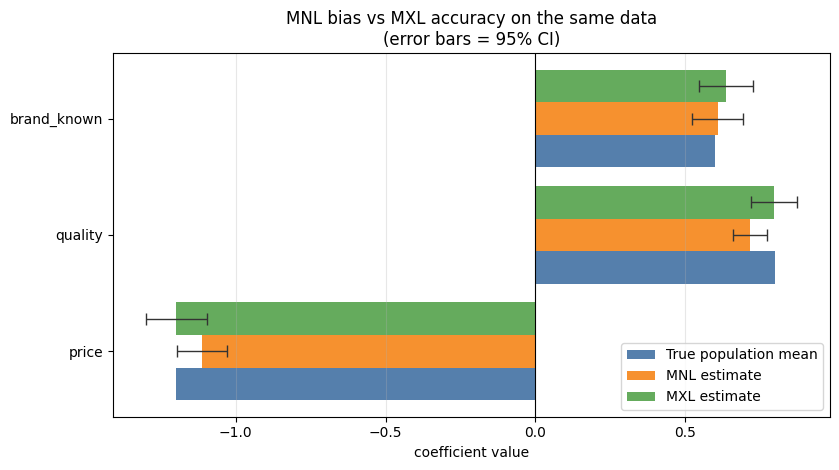

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Pull the parameters that appear in BOTH models (the means + the fixed coef).
# MXL also estimates SDs, but those have no MNL counterpart.
common_attrs = ["price", "quality", "brand_known"]

mnl_est = dict(zip(mnl.coef_names, mnl.coefficients, strict=True))
mnl_se  = dict(zip(mnl.coef_names, mnl.std_errors,  strict=True))

mxl_means = {
    "price":       (estimate["price [mean]"],   se["price [mean]"]),
    "quality":     (estimate["quality [mean]"], se["quality [mean]"]),
    "brand_known": (estimate["brand_known"],    se["brand_known"]),
}

true_means = {"price": -1.2, "quality": 0.8, "brand_known": 0.6}

fig, ax = plt.subplots(figsize=(8.5, 4.8))
y = np.arange(len(common_attrs))
height = 0.28

# True
ax.barh(y - height, [true_means[a] for a in common_attrs], height,
        label="True population mean", color="#4C78A8", alpha=0.95)
# MNL
ax.barh(y, [mnl_est[a] for a in common_attrs], height,
        label="MNL estimate", color="#F58518", alpha=0.9,
        xerr=[1.96 * mnl_se[a] for a in common_attrs], capsize=4,
        error_kw={"ecolor": "#333", "lw": 1})
# MXL
ax.barh(y + height, [mxl_means[a][0] for a in common_attrs], height,
        label="MXL estimate", color="#54A24B", alpha=0.9,
        xerr=[1.96 * mxl_means[a][1] for a in common_attrs], capsize=4,
        error_kw={"ecolor": "#333", "lw": 1})

ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(common_attrs)
ax.set_xlabel("coefficient value")
ax.set_title("MNL bias vs MXL accuracy on the same data\n"
             "(error bars = 95% CI)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

For `price` and `quality`, the orange (MNL) bars are visibly shorter
than the blue (truth) — the attenuation we saw in notebook 01. The green
(MXL) bars match the blue. The 95% CIs straddle the truth.

For `brand_known`, all three bars line up. That is exactly what should
happen for a homogeneous attribute: MXL has the *option* to estimate
heterogeneity if the data demands it, but here the data don't, and MXL
does not invent any.

## 5. The heterogeneity MNL never saw

MXL doesn't just give you a better point estimate of the mean — it gives
you the entire *distribution* of preferences across the population. We can
plot the recovered distributions and overlay the true ones to verify the
match visually.

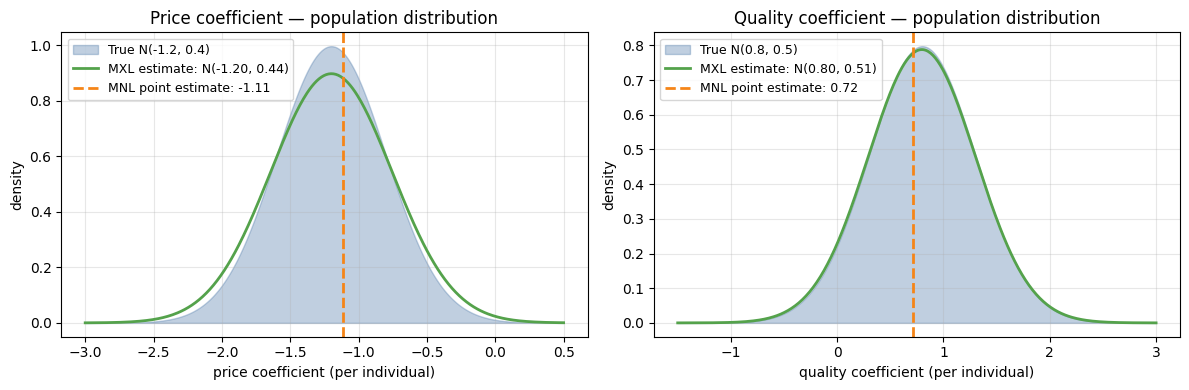

In [5]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: price coefficient distribution
xs = np.linspace(-3.0, 0.5, 400)
ax = axes[0]
ax.fill_between(xs, stats.norm.pdf(xs, loc=-1.2, scale=0.4),
                alpha=0.35, color="#4C78A8", label="True N(-1.2, 0.4)")
ax.plot(xs, stats.norm.pdf(xs,
                           loc=estimate["price [mean]"],
                           scale=estimate["price [sd]"]),
        color="#54A24B", lw=2,
        label=f"MXL estimate: N({estimate['price [mean]']:.2f}, "
              f"{estimate['price [sd]']:.2f})")
ax.axvline(mnl_est["price"], color="#F58518", ls="--", lw=2,
           label=f"MNL point estimate: {mnl_est['price']:.2f}")
ax.set_title("Price coefficient — population distribution")
ax.set_xlabel("price coefficient (per individual)")
ax.set_ylabel("density")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)

# Right panel: quality coefficient distribution
xs = np.linspace(-1.5, 3.0, 400)
ax = axes[1]
ax.fill_between(xs, stats.norm.pdf(xs, loc=0.8, scale=0.5),
                alpha=0.35, color="#4C78A8", label="True N(0.8, 0.5)")
ax.plot(xs, stats.norm.pdf(xs,
                           loc=estimate["quality [mean]"],
                           scale=estimate["quality [sd]"]),
        color="#54A24B", lw=2,
        label=f"MXL estimate: N({estimate['quality [mean]']:.2f}, "
              f"{estimate['quality [sd]']:.2f})")
ax.axvline(mnl_est["quality"], color="#F58518", ls="--", lw=2,
           label=f"MNL point estimate: {mnl_est['quality']:.2f}")
ax.set_title("Quality coefficient — population distribution")
ax.set_xlabel("quality coefficient (per individual)")
ax.set_ylabel("density")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The blue shaded region is the true population distribution we used to
generate the data. The green curve is what MXL recovered. They overlap
almost perfectly.

The orange dashed line is what MNL produces — a single number, with no
notion of distribution at all. It happens to be biased toward zero, but
even if it weren't, **MNL fundamentally cannot answer questions like
"what fraction of customers value quality above 1.0?"** because it has no
distribution to integrate over.

That distributional information is what powers the next two notebooks:
elasticities (substitution patterns that depend on which segments share
preferences) and willingness-to-pay distributions (which require both
numerator and denominator to vary).

## 6. Note on standard errors

The MXL standard errors above come from the inverse of the numerical
Hessian of the simulated log-likelihood at the optimum. With Halton draws
held fixed during optimization the Hessian is well-defined and stable.

A few caveats worth knowing:

- The SEs are **asymptotic** — based on the inverse-Hessian approximation
  to the variance-covariance matrix. With ~500 individuals and ~4000
  choice situations, this is fine; with much smaller samples, consider
  bootstrap.
- Numerical Hessian inversion can occasionally produce tiny negative
  diagonal entries (numerical error around the optimum). The library
  reports `sqrt(max(0, var))` to keep SEs real, which means in the rare
  case of a problem you'll see an SE of `0.000` — interpret that as
  "the Hessian was non-PD here, treat with skepticism" rather than
  "this estimate is exact".
- The slow tests in CI re-run the whole estimation across multiple seeds
  on every weekly schedule, asserting that all five parameters land
  within ~2.5 SE of the truth. That is how we know the SEs are
  well-calibrated, not just approximately right.


## What's next

- **Notebook 03** computes own- and cross-price elasticities under both
  models and shows how MNL's IIA assumption produces unrealistic
  substitution patterns that MXL doesn't.
- **Notebook 04** turns MXL coefficients into willingness-to-pay
  distributions per attribute, with feature ranking by population
  median WTP.

The deeper point of this notebook: **the gap between MNL and MXL is not
about model fit, it is about what questions you can answer.** MNL gives
you population-average effects; MXL gives you population *distributions*
of effects. That distinction matters whenever heterogeneous responses are
the point of the analysis — segmentation, targeting, dynamic pricing,
revenue management.
